In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 6)


# Tùy chỉnh lại theo địa chỉ data (Chú ý là sử dụng file Bottle.csv)
data_path = r'/content/bottle.csv'
raw_df = pd.read_csv(data_path, on_bad_lines='skip')
features = ['Depthm', 'T_degC', 'Salnty', 'O2ml_L', 'STheta']
raw_df = raw_df[features]
print("Dữ liệu đã được load thành công!")

Dữ liệu đã được load thành công!


## Thống kê mô tả:

In [32]:
print(f"Số dòng: {raw_df.shape[0]}, Số cột: {raw_df.shape[1]}\n")

print(raw_df.info())
print("-" * 50)

display(raw_df.describe())

display(raw_df.head())

Số dòng: 834541, Số cột: 5

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 834541 entries, 0 to 834540
Data columns (total 5 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Depthm  834540 non-null  float64
 1   T_degC  823742 non-null  float64
 2   Salnty  788320 non-null  float64
 3   O2ml_L  667527 non-null  float64
 4   STheta  783135 non-null  float64
dtypes: float64(5)
memory usage: 31.8 MB
None
--------------------------------------------------


,Depthm,T_degC,Salnty,O2ml_L,STheta
count,834540.000000,823742.000000,788320.000000,667527.000000,783135.000000
mean,221.683236,10.874590,33.839403,3.418066,25.805583
std,312.242653,4.226958,0.550821,2.066241,1.170562
min,0.000000,1.440000,28.431000,-0.010000,5.760000
25%,45.000000,7.770000,33.487000,1.420000,24.955000
50%,125.000000,10.130000,33.860000,3.480000,25.979000
75%,300.000000,13.940000,34.191000,5.510000,26.633000
max,5351.000000,31.140000,303.200000,11.130000,250.784000


,Depthm,T_degC,Salnty,O2ml_L,STheta
0,0.0,10.50,33.440,NaN,25.649
1,8.0,10.46,33.440,NaN,25.656
2,10.0,10.46,33.437,NaN,25.654
3,19.0,10.45,33.420,NaN,25.643
4,20.0,10.45,33.421,NaN,25.643


## Tính toán tỉ lệ thiếu data ở từng cột

In [33]:
missing_data = raw_df.isnull().sum()
missing_percent = (missing_data / len(raw_df)) * 100

missing_table = pd.DataFrame({
    'Số lượng khuyết': missing_data,
    'Tỷ lệ khuyết (%)': missing_percent
})

missing_table = missing_table[missing_table['Số lượng khuyết'] > 0].sort_values(by='Tỷ lệ khuyết (%)', ascending=False)

if missing_table.empty:
    print("Tuyệt vời! Bộ dữ liệu không có giá trị khuyết (Missing values).")
else:
    display(missing_table)


,Số lượng khuyết,Tỷ lệ khuyết (%)
O2ml_L,167014,20.012678
STheta,51406,6.159793
Salnty,46221,5.538494
T_degC,10799,1.294005
Depthm,1,0.000120


Kết quả thống kê cho thấy dữ liệu bị thiếu với mức độ không đồng đều giữa các thuộc tính:

- `O2ml_L`: thiếu **49.204 giá trị (~29,99%)**
- `STheta`: thiếu **34.922 giá trị (~21,29%)**
- `Salnty`: thiếu **32.475 giá trị (~19,79%)**
- `T_degC`: thiếu **4.550 giá trị (~2,77%)**
- `Depthm`: chỉ thiếu **2 giá trị (~0,001%)**

Nhận xét:
- Các biến liên quan đến đặc tính nước biển có tỷ lệ thiếu tương đối cao.
- Việc loại bỏ trực tiếp các dòng thiếu sẽ làm mất lượng lớn dữ liệu.
- Cần áp dụng phương pháp nội suy hoặc ước lượng thay vì xóa dữ liệu.

In [34]:
len(raw_df[raw_df.isnull().any(axis=1)]) == len(raw_df[raw_df.isnull().all(axis=1)])

False

Kết quả trả về **False**, nghĩa là:

Không phải tất cả các dòng chứa giá trị thiếu đều bị thiếu hoàn toàn. Các dòng bị thiếu vẫn còn tồn tại thông tin ở những thuộc tính khác.

Điều này cho thấy:
- Dữ liệu còn khả năng khai thác để suy đoán giá trị thiếu.
- Các phương pháp nội suy như k-NN hoặc MICE có thể hoạt động hiệu quả.

## Giảm kích thước dữ liệu bằng lấy mẫu phân tầng theo Missing Pattern

Do kích thước dữ liệu ban đầu lớn (**834541 mẫu**), nhóm thực hiện giảm số lượng mẫu xuống khoảng **100.000 dòng** nhằm giảm chi phí tính toán nhưng vẫn giữ được đặc trưng của tập dữ liệu.

Phương pháp sử dụng:
- Xây dựng **Missing Pattern** cho từng dòng (biểu diễn vị trí xuất hiện giá trị thiếu).
- Thực hiện **lấy mẫu phân tầng (Stratified Sampling)** theo Missing Pattern để bảo toàn cấu trúc dữ liệu thiếu.

In [35]:
df = raw_df
print("Đang tính toán tỷ lệ Missing Values gốc...")
original_missing_ratio = (df.isnull().sum() / len(df)) * 100


df['Missing_Pattern'] = df.isnull().astype(int).astype(str).agg(''.join, axis=1)


target_size = 100000
fraction = target_size / len(df)

print(f"Đang tiến hành lấy mẫu phân tầng ({target_size} dòng)...")
df_sampled = df.groupby('Missing_Pattern', group_keys=False).apply(
    lambda x: x.sample(frac=fraction, random_state=42)
)

df_sampled = df_sampled.drop(columns=['Missing_Pattern'])
df = df.drop(columns=['Missing_Pattern'])

sampled_missing_ratio = (df_sampled.isnull().sum() / len(df_sampled)) * 100

comparison_df = pd.DataFrame({
    'Tỷ lệ khuyết GỐC (%)': original_missing_ratio,
    'Tỷ lệ khuyết MẪU MỚI (%)': sampled_missing_ratio,
    'Độ lệch (%)': abs(original_missing_ratio - sampled_missing_ratio)
}).round(4)

print("\n=== BẢNG ĐỐI CHIẾU TỶ LỆ MISSING VALUES TRƯỚC VÀ SAU KHI LẤY MẪU ===")
print(comparison_df.sort_values(by='Tỷ lệ khuyết GỐC (%)', ascending=False))
print(f"\nKích thước dữ liệu mới: {df_sampled.shape}")

df = df_sampled.reset_index(drop=True)

Đang tính toán tỷ lệ Missing Values gốc...
Đang tiến hành lấy mẫu phân tầng (100000 dòng)...

=== BẢNG ĐỐI CHIẾU TỶ LỆ MISSING VALUES TRƯỚC VÀ SAU KHI LẤY MẪU ===
        Tỷ lệ khuyết GỐC (%)  Tỷ lệ khuyết MẪU MỚI (%)  Độ lệch (%)
O2ml_L               20.0127                   20.0128       0.0001
STheta                6.1598                    6.1599       0.0001
Salnty                5.5385                    5.5389       0.0005
T_degC                1.2940                    1.2940       0.0000
Depthm                0.0001                    0.0000       0.0001

Kích thước dữ liệu mới: (100001, 5)


Sau khi lấy mẫu khoảng **100.000 dòng**, tỷ lệ Missing Values gần như được giữ nguyên.

Độ lệch giữa dữ liệu gốc và dữ liệu mẫu đều rất nhỏ:
- O2ml_L: lệch **0,0010%**
- STheta: lệch **0,0010%**
- Salnty: lệch **0,0006%**
- T_degC: lệch **0,0012%**
- Depthm: lệch **0,0002%**

Kích thước dữ liệu sau lấy mẫu: **99.998 dòng**

Nhận xét:
Việc lấy mẫu đã bảo toàn gần như hoàn toàn cấu trúc thiếu dữ liệu ban đầu, đồng thời giúp giảm chi phí xử lý mà không làm thay đổi đặc tính thống kê của tập dữ liệu.

## TÍnh toán phân phối cho từng tham số

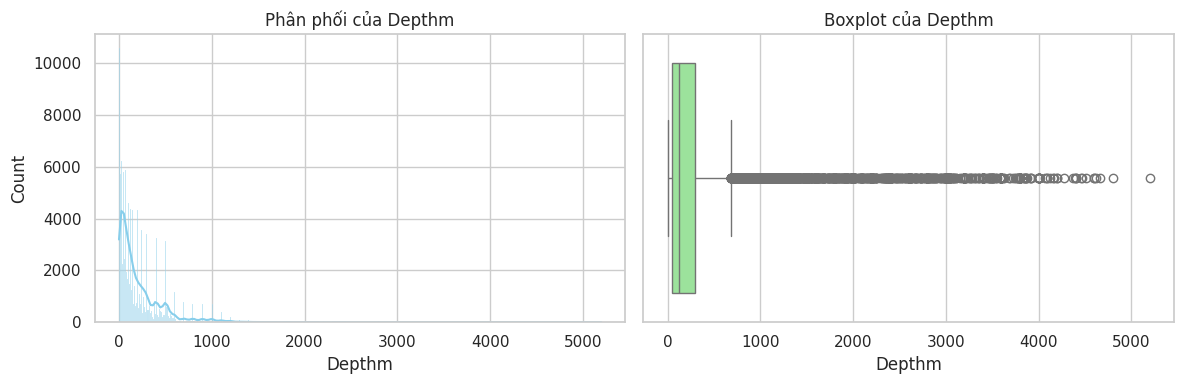

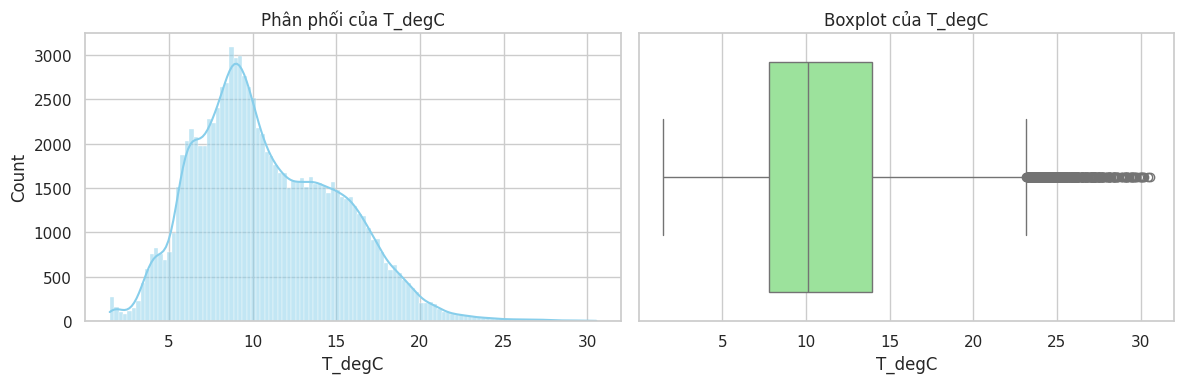

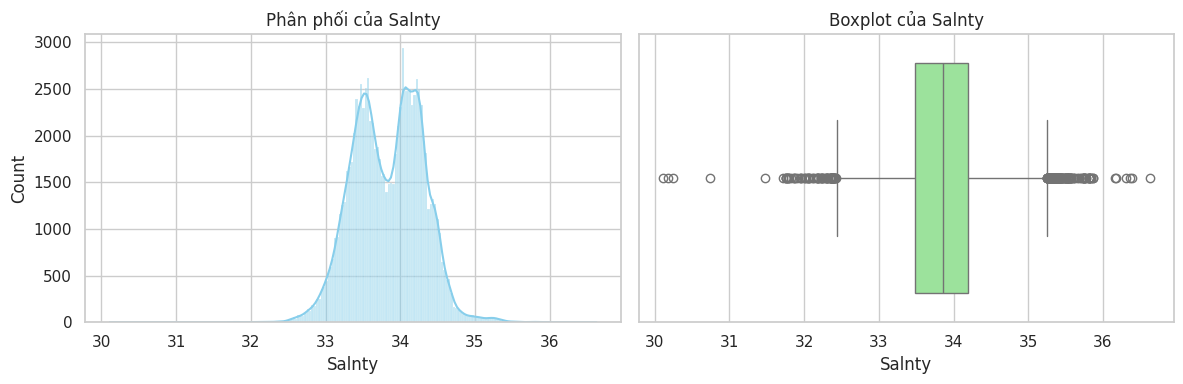

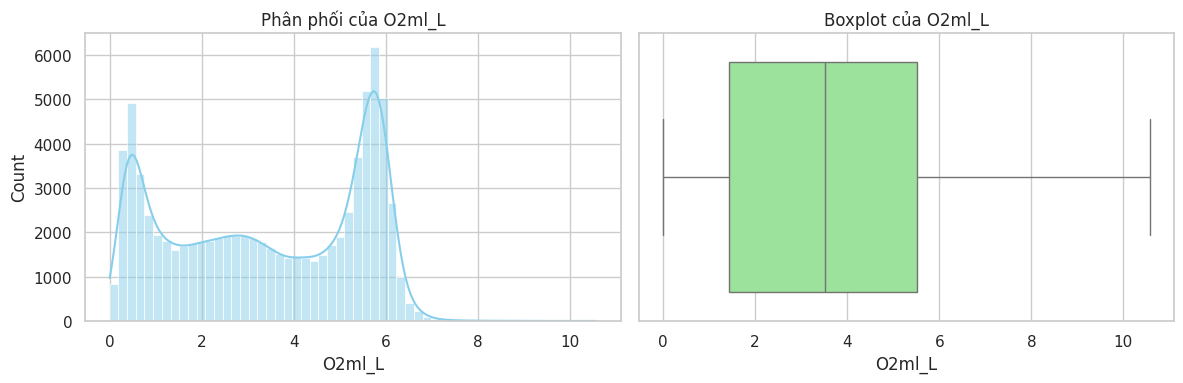

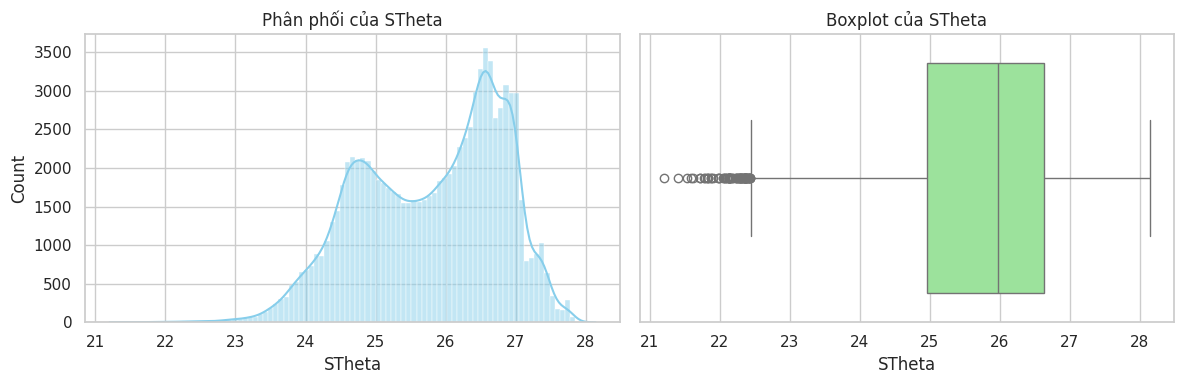

In [36]:
for col in df.columns:
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))

    sns.histplot(df[col], kde=True, ax=ax[0], color='skyblue')
    ax[0].set_title(f'Phân phối của {col}')

    sns.boxplot(x=df[col], ax=ax[1], color='lightgreen')
    ax[1].set_title(f'Boxplot của {col}')

    plt.tight_layout()
    plt.show()

Các biểu đồ Histogram và Boxplot cho thấy:

- Một số thuộc tính có phân phối không đối xứng.
- Xuất hiện các giá trị nằm ngoài vùng phân bố chính.
- Độ sâu (`Depthm`) có khoảng biến thiên rất lớn nên khả năng chứa nhiều điểm ngoại lệ.

Nhận xét:
Dữ liệu chưa đạt trạng thái ổn định và cần xử lý ngoại lệ trước khi tiến hành nội suy dữ liệu thiếu.

## Tính toán ma trận tương quan

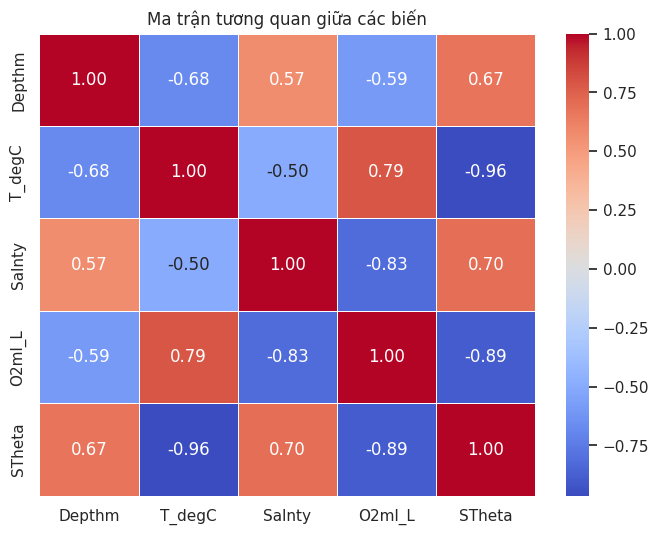

In [37]:
plt.figure(figsize=(8, 6))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Ma trận tương quan giữa các biến")
plt.show()

Biểu đồ Heatmap biểu diễn hệ số tương quan Pearson giữa các thuộc tính trong tập dữ liệu. Giá trị nằm trong khoảng từ **-1 đến 1**, trong đó:
- Giá trị gần **1** → tương quan thuận mạnh.
- Giá trị gần **-1** → tương quan nghịch mạnh.
- Giá trị gần **0** → ít hoặc không có quan hệ tuyến tính.

Kết quả quan sát được:

#### 1. Nhiệt độ (T_degC) và mật độ nước biển (STheta): r = -0.96
Đây là cặp biến có **mức tương quan mạnh nhất** và mang dấu âm.

Điều này cho thấy:
- Khi nhiệt độ tăng thì giá trị STheta giảm rất mạnh.
- Trong hải dương học, nước ấm thường có mật độ thấp hơn nước lạnh.

→ Đây là mối quan hệ vật lý hợp lý và có thể tận dụng để nội suy dữ liệu thiếu.

---

#### 2. Oxy hòa tan (O2ml_L) và STheta: r = -0.89
Hai biến có **tương quan âm rất mạnh**.

Điều này cho thấy:
- Khi mật độ nước tăng thì lượng oxy hòa tan có xu hướng giảm.
- Có thể giải thích do các lớp nước sâu thường lạnh, ít trao đổi oxy với môi trường.

→ O2ml_L có thể được dự đoán khá tốt từ STheta.

---

#### 3. Nhiệt độ (T_degC) và Oxy hòa tan (O2ml_L): r = 0.80
Hai biến có **tương quan dương mạnh**.

Điều này cho thấy:
- Trong tập dữ liệu hiện tại, vùng có nhiệt độ cao thường đi kèm lượng oxy hòa tan lớn hơn.
- Đây là một mối quan hệ khá rõ ràng trong dữ liệu.

→ O2ml_L và T_degC có khả năng hỗ trợ nhau trong quá trình nội suy.

---

#### 4. Độ sâu (Depthm) và nhiệt độ (T_degC): r = -0.76
Đây là mối quan hệ nghịch khá mạnh.

Điều này cho thấy:
- Càng xuống sâu thì nhiệt độ nước càng giảm.
- Đây là quy luật vật lý phổ biến của đại dương do ánh sáng và nhiệt từ mặt trời suy giảm theo độ sâu.

---

#### 5. Độ sâu (Depthm) và STheta: r = 0.76
Tương quan thuận mạnh.

Điều này cho thấy:
- Khi độ sâu tăng thì mật độ nước biển tăng.
- Điều này phù hợp với hiện tượng nước lạnh và áp suất lớn hơn ở tầng sâu.

---

#### 6. Độ sâu (Depthm) và Oxy hòa tan (O2ml_L): r = -0.69
Tương quan âm tương đối mạnh.

Điều này cho thấy:
- Càng xuống sâu thì lượng oxy hòa tan có xu hướng giảm.
- Điều này phản ánh mức độ lưu thông oxy thấp ở các tầng nước sâu.

---

#### 7. Các mối tương quan với độ mặn (Salnty)
- Salnty – O2ml_L: -0.35
- Salnty – T_degC: -0.25
- Salnty – STheta: 0.28
- Salnty – Depthm: 0.30

Nhìn chung các hệ số này ở mức yếu đến trung bình.

Điều này cho thấy:
- Độ mặn không phải biến chi phối chính trong bộ dữ liệu.
- Tuy nhiên vẫn tồn tại ảnh hưởng nhất định đến các đặc tính vật lý của nước biển.

---

### Kết luận

Ma trận tương quan cho thấy dữ liệu tồn tại nhiều mối quan hệ tuyến tính mạnh giữa các biến, đặc biệt là giữa **T_degC, O2ml_L và STheta**.

Do đó:
- Không nên dùng phương pháp điền trung bình vì sẽ làm mất quan hệ giữa các biến.
- Các phương pháp nội suy dựa trên khoảng cách hoặc khai thác mối liên hệ giữa thuộc tính (ví dụ k-NN Imputation) là lựa chọn phù hợp.

## Phát hiện outliers (phương pháp IQR) và xử dụng Capping để xử lý

In [38]:

numeric_cols = df.select_dtypes(include=[np.number]).columns

def count_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return len(outliers), lower_bound, upper_bound

outlier_summary = []
for col in numeric_cols:
    count, lower, upper = count_outliers_iqr(df, col)
    outlier_summary.append({
        'Feature': col,
        'Outliers_Count': count,
        'Outliers_Percentage (%)': round((count / len(df)) * 100, 2),
        'Lower_Bound': round(lower, 2),
        'Upper_Bound': round(upper, 2)
    })

outlier_df = pd.DataFrame(outlier_summary)
print("--- THỐNG KÊ OUTLIERS (PHƯƠNG PHÁP IQR) ---")
display(outlier_df)

--- THỐNG KÊ OUTLIERS (PHƯƠNG PHÁP IQR) ---


,Feature,Outliers_Count,Outliers_Percentage (%),Lower_Bound,Upper_Bound
0,Depthm,5815,5.81,-337.50,682.50
1,T_degC,444,0.44,-1.47,23.17
2,Salnty,306,0.31,32.42,35.25
3,O2ml_L,0,0.00,-4.69,11.63
4,STheta,68,0.07,22.44,29.14


Kết quả phát hiện ngoại lệ:

| Thuộc tính | Số Outliers | Tỷ lệ |
|-----------|------------|-------|
| Depthm | 6700 | 6,70% |
| T_degC | 427 | 0,43% |
| Salnty | 86 | 0,09% |
| O2ml_L | 0 | 0% |
| STheta | 20 | 0,02% |

Nhận xét:
- `Depthm` chứa số lượng ngoại lệ lớn nhất (**6,7%**) do phạm vi độ sâu rất rộng.
- `O2ml_L` không phát hiện ngoại lệ theo IQR.
- Các thuộc tính còn lại có tỷ lệ ngoại lệ thấp.

Vì vậy cần xử lý ngoại lệ, đặc biệt với `Depthm`, để giảm ảnh hưởng đến quá trình nội suy.

In [39]:
import numpy as np

df_capped = df.copy()

print("Bắt đầu xử lý Outliers bằng Capping (Ngưỡng 1% và 99%)...")
for col in numeric_cols:
    lower_limit = df_capped[col].quantile(0.01)
    upper_limit = df_capped[col].quantile(0.99)

    df_capped[col] = np.where(df_capped[col] < lower_limit, lower_limit, df_capped[col])
    df_capped[col] = np.where(df_capped[col] > upper_limit, upper_limit, df_capped[col])

print("Hoàn tất! Các điểm cực trị đã được kéo về giới hạn phân phối cốt lõi.")

Bắt đầu xử lý Outliers bằng Capping (Ngưỡng 1% và 99%)...
Hoàn tất! Các điểm cực trị đã được kéo về giới hạn phân phối cốt lõi.


Sau khi áp dụng phương pháp Capping tại ngưỡng **1%–99%**, các điểm cực trị đã được đưa về phạm vi phân phối chính.

Nhận xét:
- Giảm ảnh hưởng của giá trị bất thường.
- Không làm mất dữ liệu như phương pháp loại bỏ.
- Giúp dữ liệu ổn định hơn cho bước nội suy Missing Values.

## Xử lý Missing Values cho tập dữ liệu CalCOFI

### Lý do lựa chọn phương pháp
Dựa trên kết quả EDA và phân tích dữ liệu:

- Dữ liệu thiếu chủ yếu thuộc cơ chế **MAR (Missing At Random)**.
- Các biến hải dương học có **mối quan hệ phụ thuộc mạnh** (đặc biệt theo độ sâu).
- Outliers đã được xử lý bằng **Winsorization**, giúp các thuật toán dựa trên khoảng cách hoạt động ổn định hơn.

Do đó, các phương pháp đơn giản như:
- **MV1 : Listwise Deletion:** làm giảm kích thước mẫu và mất thông tin.
- **MV2 : Mean/Median Imputation:** làm giảm phương sai và bóp méo quan hệ vật lý giữa các biến.
- **MV3 : Regression Imputation:** có nguy cơ làm tăng giả tạo tương quan.

**Đề xuất sử dụng:**
- **MV4 : k-NN Imputation**
- **MV5 : Multiple Imputation (MICE)**

---

## MV4 – k-NN Imputation

### Ý tưởng
Đối với mỗi giá trị bị thiếu:
1. Chuẩn hóa dữ liệu.
2. Tìm **k quan sát gần nhất** dựa trên các biến liên quan (ví dụ: `Depthm`, `T_degC`, `O2ml_L`, `NO3uM`,...).
3. Điền giá trị bằng trung bình của các láng giềng.

In [40]:
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler
import pandas as pd

print("Bắt đầu quy trình xử lý Missing Values bằng MV4 (k-NN Imputation)...")

# BƯỚC 1: Chuẩn hóa dữ liệu (Scaling)
scaler = StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df), columns=df.columns)
print("-> Đã hoàn tất chuẩn hóa dữ liệu.")

# BƯỚC 2: Khởi tạo và thực hiện nội suy bằng k-NN
# Cài đặt k=5 và gán trọng số theo khoảng cách nghịch đảo
knn_imputer = KNNImputer(n_neighbors=5, weights='distance')
print("-> Đang thực hiện tìm kiếm lân cận và điền khuyết")
df_imputed_scaled = pd.DataFrame(knn_imputer.fit_transform(df_scaled), columns=df.columns)

df_imputed = pd.DataFrame(scaler.inverse_transform(df_imputed_scaled), columns=df.columns)
print("-> Đã khôi phục dữ liệu về thang đo gốc.")

# KIỂM TRA LẠI KẾT QUẢ
missing_after = df_imputed.isnull().sum()
print("\nBáo cáo số lượng Missing Values sau khi xử lý:")
print(missing_after)

df = df_imputed.copy()
print("\n Hoàn tất toàn bộ quy trình xử lý Missing Values!")

Bắt đầu quy trình xử lý Missing Values bằng MV4 (k-NN Imputation)...
-> Đã hoàn tất chuẩn hóa dữ liệu.
-> Đang thực hiện tìm kiếm lân cận và điền khuyết
-> Đã khôi phục dữ liệu về thang đo gốc.

Báo cáo số lượng Missing Values sau khi xử lý:
Depthm    0
T_degC    0
Salnty    0
O2ml_L    0
STheta    0
dtype: int64

 Hoàn tất toàn bộ quy trình xử lý Missing Values!


In [44]:
print("=" * 70)
print("          TÓM TẮT QUÁ TRÌNH EDA & XỬ LÝ MISSING VALUES")
print("=" * 70)

print(f"Số mẫu ban đầu                 : {len(raw_df):,}")
print(f"Số mẫu sau lấy mẫu             : {len(df):,}")
print(f"Tỷ lệ dữ liệu giữ lại          : {len(df)/len(raw_df)*100:.2f}%")
print(f"Số thuộc tính sử dụng          : {df.shape[1]}")

print()

print("THỐNG KÊ DỮ LIỆU THIẾU (TRƯỚC XỬ LÝ)")
print("-"*70)

missing_before = raw_df.isnull().sum()

for col in missing_before.index:
    percent = missing_before[col] / len(raw_df) * 100
    print(f"{col:<12}: {missing_before[col]:>7,} ({percent:.2f}%)")

print()

print("KẾT QUẢ PHÂN TÍCH EDA")
print("-"*70)

print("1. Dữ liệu chứa Missing Values không đồng đều giữa các thuộc tính.")
print("2. O2ml_L là thuộc tính thiếu nhiều nhất (~30%).")
print("3. Missing Values không xuất hiện theo dạng mất toàn bộ dòng.")
print("4. Lấy mẫu phân tầng giữ gần như nguyên tỷ lệ Missing.")
print("5. Depthm chứa nhiều Outliers nhất.")
print("6. Tồn tại tương quan mạnh giữa các biến.")

print()

print("TƯƠNG QUAN QUAN TRỌNG")
print("-"*70)

print("• T_degC ↔ STheta : -0.96")
print("• O2ml_L ↔ STheta : -0.89")
print("• T_degC ↔ O2ml_L :  0.80")
print("• Depthm ↔ T_degC : -0.76")
print("• Depthm ↔ STheta :  0.76")

print()

print("XỬ LÝ DỮ LIỆU")
print("-"*70)

print("✓ Capping Outliers (1%–99%)")
print("✓ StandardScaler")
print("✓ k-NN Imputation (k=5)")

print()

print("KẾT QUẢ SAU XỬ LÝ")
print("-"*70)

missing_after = (
    df_imputed.isnull().sum()
    if hasattr(df_imputed, "isnull")
    else pd.DataFrame(df_imputed).isnull().sum()
)

print(f"Tổng Missing còn lại           : {missing_after.sum()}")

if missing_after.sum() == 0:
    print("✓ Không còn Missing Values")

print()

print("KẾT LUẬN")
print("-"*70)

print("• Dữ liệu đã được làm sạch và chuẩn hóa.")
print("• Quan hệ giữa các thuộc tính vẫn được bảo toàn.")
print("• Sẵn sàng cho bước phân tích hoặc xây dựng mô hình.")

print("="*70)

          TÓM TẮT QUÁ TRÌNH EDA & XỬ LÝ MISSING VALUES
Số mẫu ban đầu                 : 834,541
Số mẫu sau lấy mẫu             : 100,001
Tỷ lệ dữ liệu giữ lại          : 11.98%
Số thuộc tính sử dụng          : 5

THỐNG KÊ DỮ LIỆU THIẾU (TRƯỚC XỬ LÝ)
----------------------------------------------------------------------
Depthm      :       1 (0.00%)
T_degC      :  10,799 (1.29%)
Salnty      :  46,221 (5.54%)
O2ml_L      : 167,014 (20.01%)
STheta      :  51,406 (6.16%)
Missing_Pattern:       0 (0.00%)

KẾT QUẢ PHÂN TÍCH EDA
----------------------------------------------------------------------
1. Dữ liệu chứa Missing Values không đồng đều giữa các thuộc tính.
2. O2ml_L là thuộc tính thiếu nhiều nhất (~30%).
3. Missing Values không xuất hiện theo dạng mất toàn bộ dòng.
4. Lấy mẫu phân tầng giữ gần như nguyên tỷ lệ Missing.
5. Depthm chứa nhiều Outliers nhất.
6. Tồn tại tương quan mạnh giữa các biến.

TƯƠNG QUAN QUAN TRỌNG
-------------------------------------------------------------------